Cell 1 - Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

from minicv.io import read_image
from minicv.techniques import (
    histogram,
    bit_plane_slice,
    histogram_equalization,
    contrast_stretching,
    laplacian_sharpening
)

Cell 2 — Image picker

In [20]:
def pick_image():
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    path = filedialog.askopenfilename(
        title="Select an image for techniques",
        filetypes=[("Image files", "*.png *.jpg *.jpeg")]
    )
    root.destroy()
    return path

IMAGE_PATH = pick_image()
img_rgb  = read_image(IMAGE_PATH, mode="rgb")
img_gray = read_image(IMAGE_PATH, mode="gray")
print(f"Image loaded: {img_gray.shape}")

Image loaded: (588, 1400)


Cell 2 — Bit-Plane Slicing

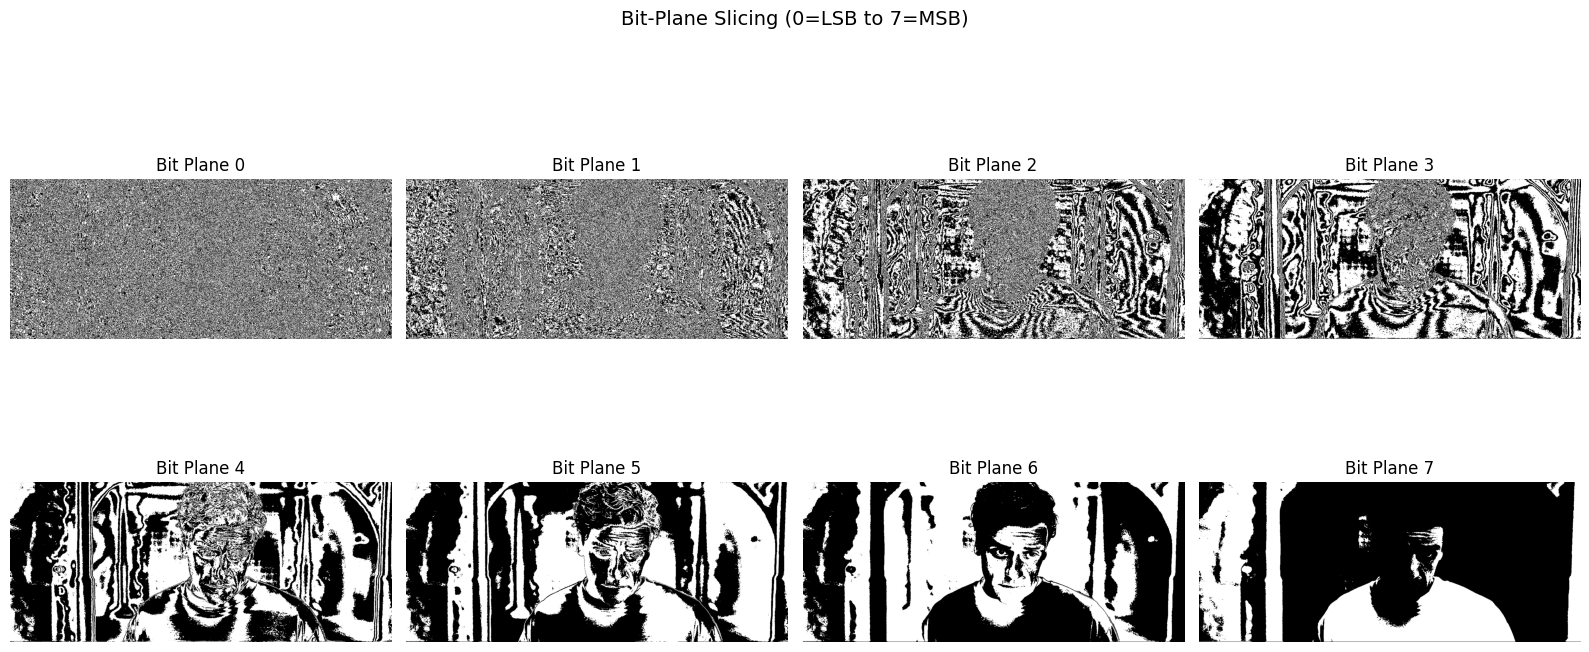

In [21]:
# Extract all 8 planes
planes = [bit_plane_slice(img_gray, bit) for bit in range(8)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(planes[i], cmap='gray')
    axes[i].set_title(f"Bit Plane {i}")
    axes[i].axis("off")

plt.suptitle("Bit-Plane Slicing (0=LSB to 7=MSB)", fontsize=14)
plt.tight_layout()
plt.show()

Cell 4 — Histogram Computation

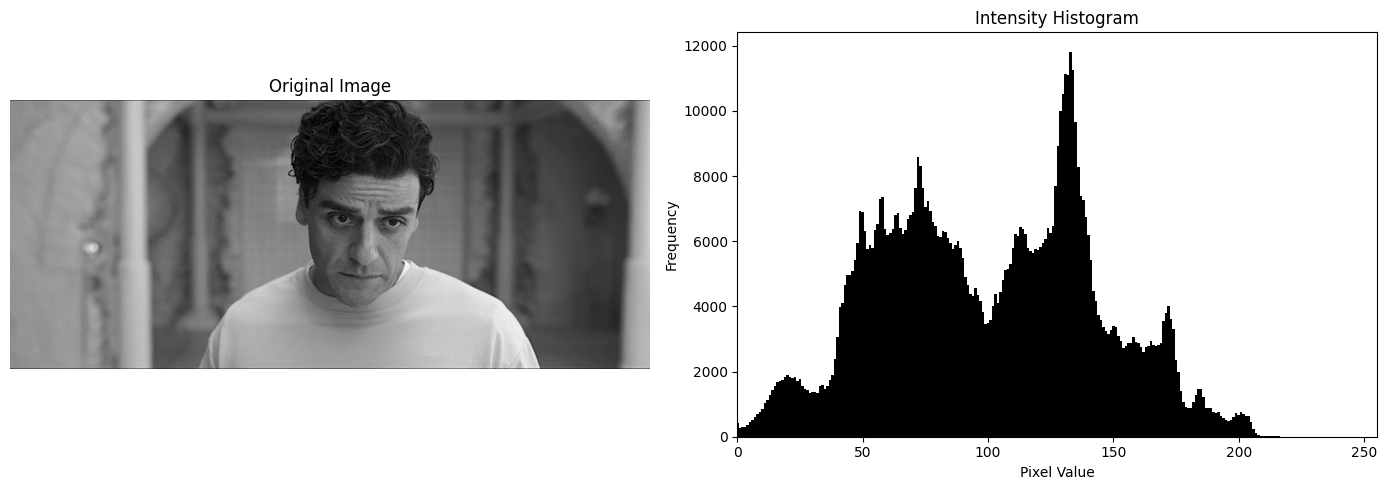

In [22]:
# Your function returns counts and bin_edges
counts, bin_edges = histogram(img_gray, bins=256)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

# Using the counts returned by your histogram function
axes[1].bar(range(256), counts, color='black', width=1.0)
axes[1].set_title("Intensity Histogram")
axes[1].set_xlim([0, 255])
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Cell 5 — Histogram Equalization

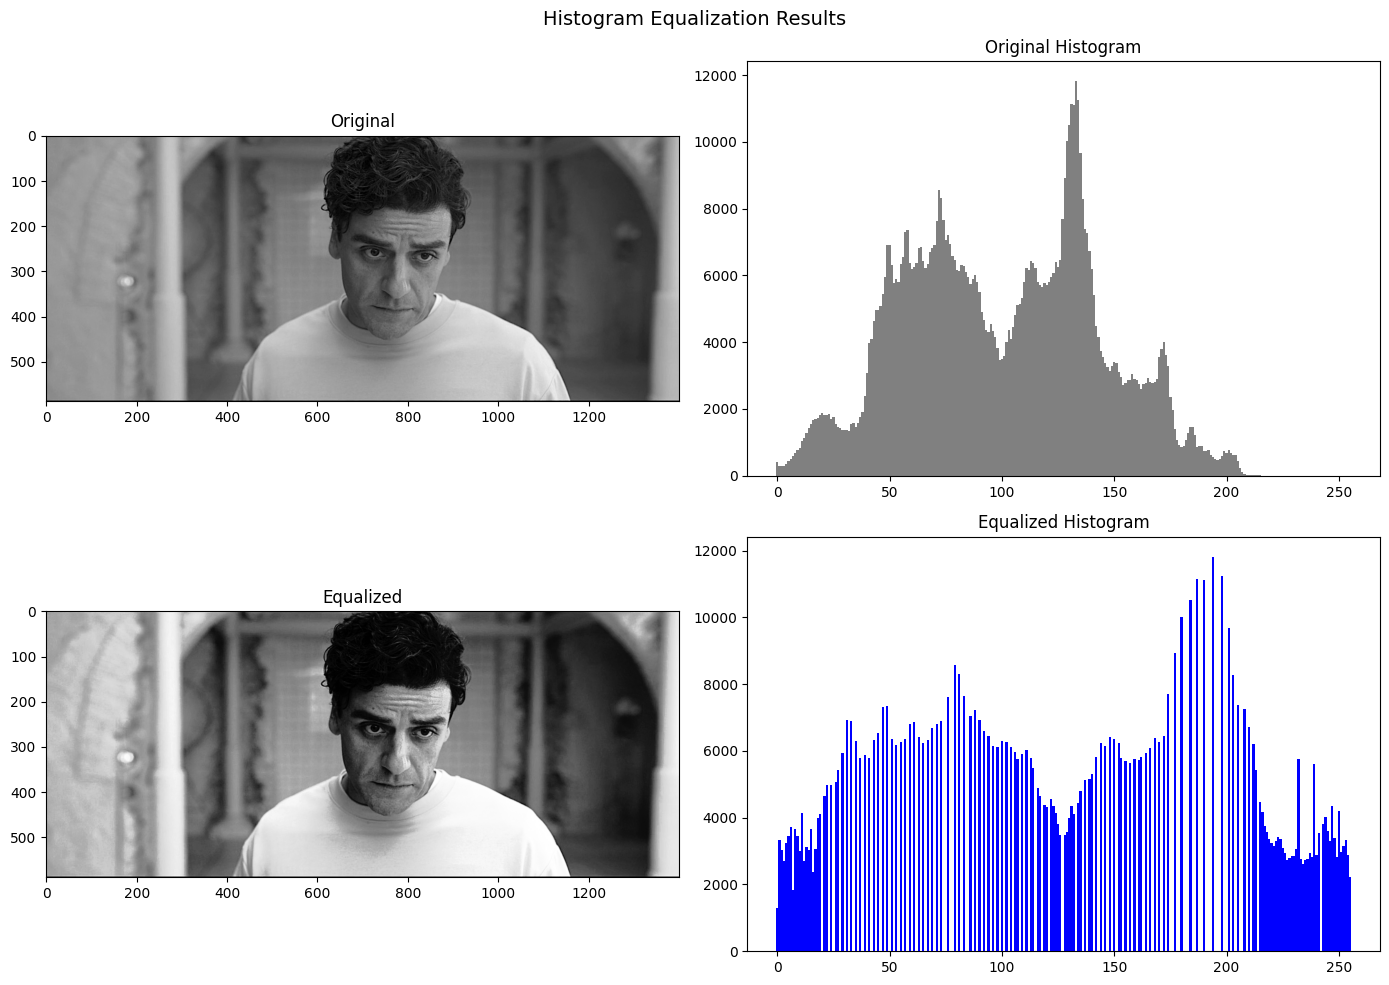

In [23]:
img_eq = histogram_equalization(img_gray)
counts_eq, _ = histogram(img_eq)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: Original
axes[0, 0].imshow(img_gray, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 1].bar(range(256), counts, color='gray', width=1.0)
axes[0, 1].set_title("Original Histogram")

# Bottom row: Equalized
axes[1, 0].imshow(img_eq, cmap="gray")
axes[1, 0].set_title("Equalized")
axes[1, 1].bar(range(256), counts_eq, color='blue', width=1.0)
axes[1, 1].set_title("Equalized Histogram")

plt.suptitle("Histogram Equalization Results", fontsize=14)
plt.tight_layout()
plt.show()

Cell 6 — Contrast Stretching

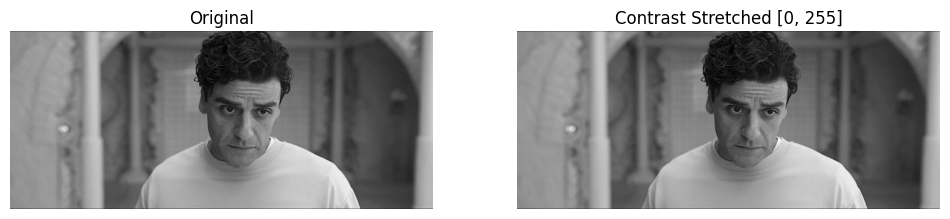

In [24]:
img_stretched = contrast_stretching(img_gray, out_low=0, out_high=255)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(img_stretched, cmap="gray")
axes[1].set_title("Contrast Stretched [0, 255]")

for ax in axes: ax.axis("off")
plt.show()

Cell 7 — Laplacian sharpening

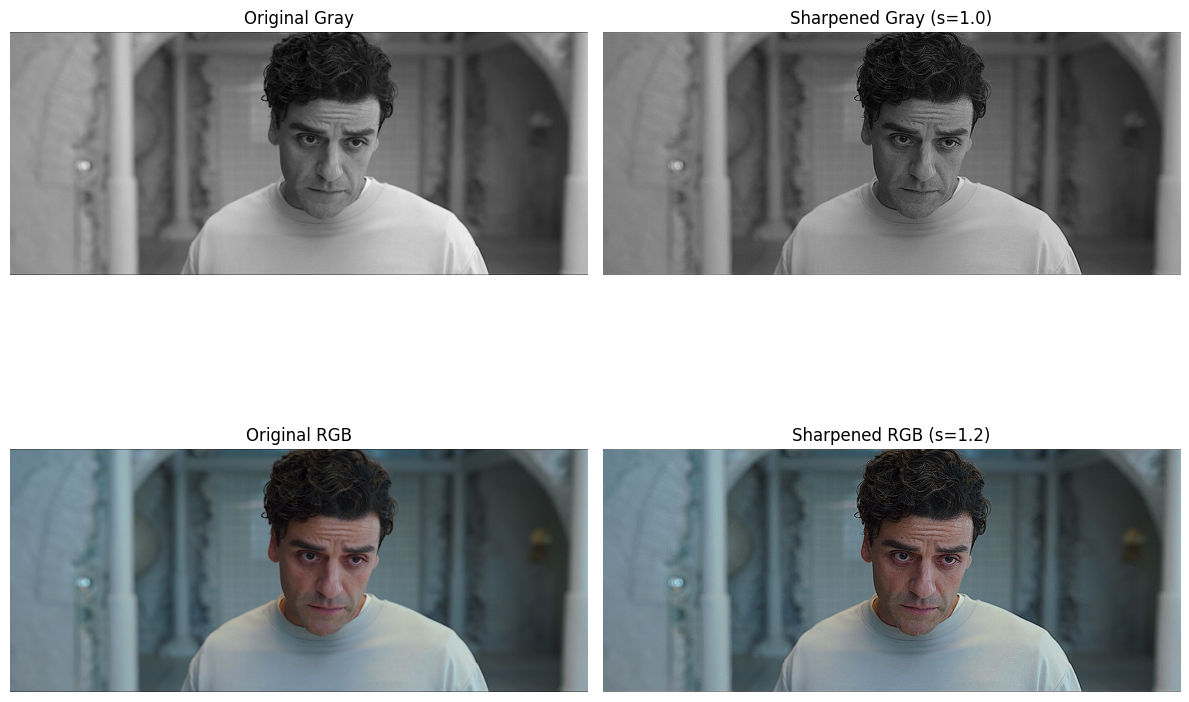

In [25]:
img_gray_sharp = laplacian_sharpening(img_gray, strength=1.0)
img_rgb_sharp  = laplacian_sharpening(img_rgb, strength=1.2)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_gray, cmap="gray")
axes[0, 0].set_title("Original Gray")
axes[0, 1].imshow(img_gray_sharp, cmap="gray")
axes[0, 1].set_title("Sharpened Gray (s=1.0)")

axes[1, 0].imshow(img_rgb)
axes[1, 0].set_title("Original RGB")
axes[1, 1].imshow(img_rgb_sharp)
axes[1, 1].set_title("Sharpened RGB (s=1.2)")

for ax in axes.ravel(): ax.axis("off")
plt.tight_layout()
plt.show()

Cell 8 — Final Comparison

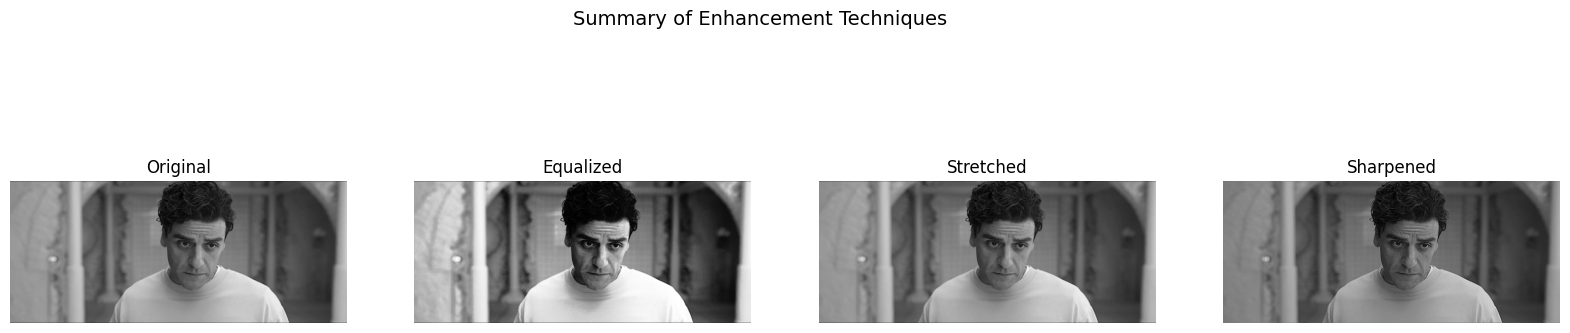

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

titles = ["Original", "Equalized", "Stretched", "Sharpened"]
imgs = [img_gray, img_eq, img_stretched, img_gray_sharp]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Summary of Enhancement Techniques", fontsize=14)
plt.show()